In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 분류

In [2]:
from sklearn.datasets import fetch_openml
from catboost import CatBoostClassifier

In [5]:
# 데이터 불러온다.
bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)
display(bank.data)
display(bank.target)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown


0        1
1        1
2        1
3        1
4        1
        ..
45206    2
45207    2
45208    2
45209    1
45210    1
Name: Class, Length: 45211, dtype: category
Categories (2, str): ['1', '2']

In [9]:
X = bank.frame.drop('Class', axis=1)
y = bank.frame['Class']

In [11]:
# 결과데이터는 0부터 1씩 증가되어 있는 형태로 되어 있어야 한다.
# 1 -> 0 , 2-> 1 로 바꾸는 작업 진행 
y = y.apply(lambda x : 1 if x=='2' else 0)
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: Class, Length: 45211, dtype: category
Categories (2, int64): [0, 1]

In [12]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown


In [13]:
# 범주형 컬럼의 이름 목록
cat_features = ['V2','V3','V4','V5','V7','V8','V9','V11','V16']

In [14]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

In [15]:
# 하이퍼 파라미터
param_grid = {
    'depth' : [4,6],
    'learning_rate' : [0.05, 0.1],
    'l2_leaf_reg' : [1,3],
    'iterations' : [100,200]
}

In [16]:
# 하이퍼 파라미터 튜닝
# 범주형 데이터에서 cat_features 사용
model = CatBoostClassifier(task_type='GPU', cat_features=cat_features, random_state=42, verbose=False)
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x0000027991A76990>,
             param_grid={'depth': [4, 6], 'iterations': [100, 200],
                         'l2_leaf_reg': [1, 3], 'learning_rate': [0.05, 0.1]})

In [17]:
# 최적의 모델 추출 및 최종학습
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9043,))

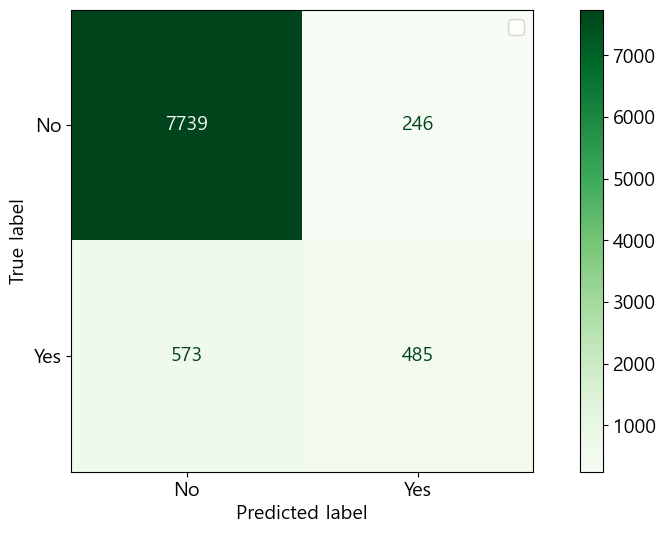

In [20]:
# 시각화
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(cmap=plt.cm.Greens)
plt.legend()
plt.show()

In [21]:
# 지표 출력
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f'최적의 파라미터 : {grid_search.best_params_}')
print(f'accuracy : {accuracy}')
print(f'precision : {precision}')
print(f'recall : {recall}')
print(f'f1 : {f1}')

최적의 파라미터 : {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}
accuracy : 0.9094327103837222
precision : 0.6634746922024624
recall : 0.45841209829867674
f1 : 0.5422023476802683


### 회귀

In [22]:
from catboost import CatBoostRegressor
from sklearn.datasets import load_diabetes

In [23]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
param_grid = {
    'iterations' : [100,200],
    'depth' : [4,6,8],
    'learning_rate' : [0.01,0.05,0.1],
    'l2_leaf_reg' : [1,3,5]
}

In [26]:
model = CatBoostRegressor(task_type='GPU', random_state=42, verbose=False)
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled,y_train)

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x0000027991DAB200>,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200],
                         'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.01, 0.05, 0.1]})

In [27]:
# 최적 모델 추출 및 예측
best_cat = grid_search.best_estimator_
y_pred = best_cat.predict(X_test_scaled)

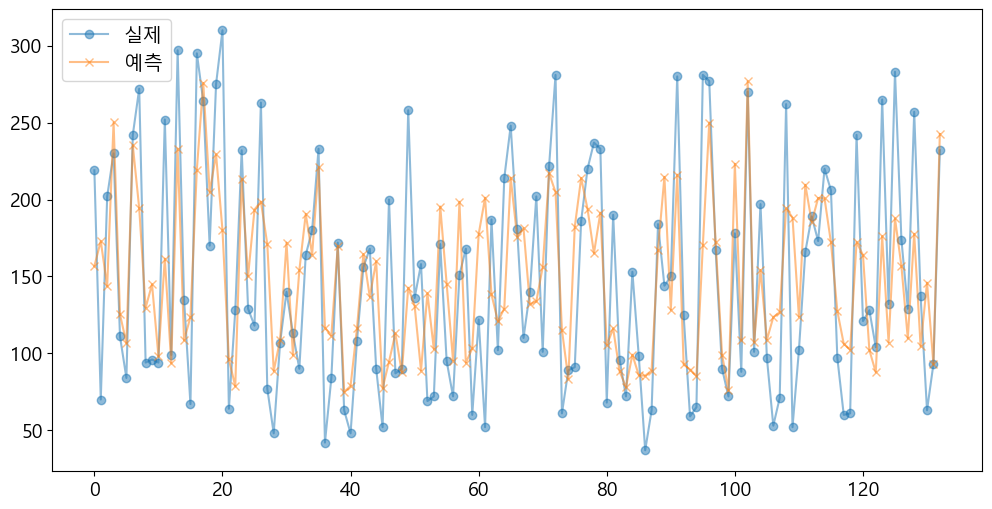

In [29]:
indices = np.arange(len(y_test))
plt.plot(indices, y_test, marker='o', label='실제', alpha=0.5)
plt.plot(indices, y_pred, marker='x', label='예측', alpha=0.5)
plt.legend()
plt.show()

In [35]:
# 평가지표
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f'최적의 파라미터 : {grid_search.best_params_}')
print(f'MAE : {mae}')
print(f'MSE : {mse}')
print(f'RMSE : {rmse}')
print(f'r2 : {r2}')

최적의 파라미터 : {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
MAE : 41.70888409686723
MSE : 2733.7346277015586
RMSE : 52.28512816950494
r2 : 0.4935941505590413
